# LangGraph framework practise

In this notebook, I aim to build an Alfred's email processing system for the following tasks:

1. Read incoming emails
2. Classify them as spam or legitimate
3. Draft a preliminary response for legitimate emails
4. Send information to Mr. Wayne when legitimate

In [1]:
# !pip install langgraph langchain_openai

In [2]:
import os, json
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

In [3]:
# define what information Alfred needs to track during the email processing workflow:

class EmailState(TypedDict):
    email: Dict[str, Any] # subject, sender, body, etc

    email_category: Optional[str] # category of the email (inquiry, complaint, etc.)

    spam_reason: Optional[str] # reason of marking spam

    is_spam: Optional[bool] # Analysis and decisions, boolean value

    email_draft: Optional [str] # response draft

    messages: List[Dict[str,Any]] # Track conversation with LLM for analysis


In [4]:
# Initialize our LLM pointing to LM Studio
model = ChatOpenAI(
    temperature=0,
    openai_api_base="http://127.0.0.1:1234/v1",
    openai_api_key="lm-studio"  # LM Studio requires a placeholder key string
)

def read_email(state: EmailState):
    """Alfred reads and logs the incoming email"""
    email = state["email"]
    
    # Here we might do some initial preprocessing
    print(f"Alfred is processing an email from {email['sender']} with subject: {email['subject']}")
    
    # No state changes needed here
    return {}

def classify_email(state: EmailState):
    """Alfred uses an LLM to determine if the email is spam or legitimate"""
    email = state["email"]
    
    # Prepare our prompt for the LLM
    prompt = f"""
    As Alfred the butler, analyze this email and provide your analysis strictly in JSON format.
    
    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}
    
    Your response must be a valid JSON object with exactly these keys:
    "is_spam": (boolean true or false),
    "reason": (a short string explaining why if spam, otherwise null),
    "category": (one of: "inquiry", "complaint", "thank you", "request", "information", or null)

    Example format:
    {{"is_spam": false, "reason": null, "category": "inquiry"}}
    """
    
    # Call the LLM
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    
    # 2. Robust JSON Parsing
    try:
        # Clean the response in case the LLM adds markdown backticks like ```json ... ```
        raw_content = response.content.strip().replace("```json", "").replace("```", "")
        data = json.loads(raw_content)
        
        is_spam = data.get("is_spam", False)
        spam_reason = data.get("reason") if is_spam else None
        email_category = data.get("category") if not is_spam else None
        
    except Exception as e:
        # Fallback logic if the LLM fails to provide valid JSON
        print(f"Error parsing LLM response: {e}")
        is_spam = False 
        spam_reason = "Parsing error"
        email_category = "unknown"

    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    
    return {
        "is_spam": is_spam,
        "spam_reason": spam_reason,
        "email_category": email_category,
        "messages": new_messages
    }

def handle_spam(state: EmailState):
    """Alfred discards spam email with a note"""
    print(f"Alfred has marked the email as spam. Reason: {state['spam_reason']}")
    print("The email has been moved to the spam folder.")
    
    # We're done processing this email
    return {}

def draft_response(state: EmailState):
    """Alfred drafts a preliminary response for legitimate emails"""
    email = state["email"]
    category = state["email_category"] or "general"
    
    # Prepare our prompt for the LLM
    prompt = f"""
    As Alfred the butler, draft a polite preliminary response to this email.
    
    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}
    
    This email has been categorized as: {category}
    
    Draft a brief, professional response that Mr. Hugg can review and personalize before sending.
    """
    
    # Call the LLM
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    
    # Update messages for tracking
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    
    # Return state updates
    return {
        "email_draft": response.content,
        "messages": new_messages
    }

def notify_mr_hugg(state: EmailState):
    """Alfred notifies Mr. Hugg about the email and presents the draft response"""
    email = state["email"]
    
    print("\n" + "="*50)
    print(f"Sir, you've received an email from {email['sender']}.")
    print(f"Subject: {email['subject']}")
    print(f"Category: {state['email_category']}")
    print("\nI've prepared a draft response for your review:")
    print("-"*50)
    print(state["email_draft"])
    print("="*50 + "\n")
    
    # We're done processing this email
    return {}

In [5]:
# routing
def route_email(state: EmailState) -> str:
    """Determine the next step based on spam classification"""
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"

In [6]:
# Create the graph
email_graph = StateGraph(EmailState)

# Add nodes
email_graph.add_node("read_email", read_email)
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("handle_spam", handle_spam)
email_graph.add_node("draft_response", draft_response)
email_graph.add_node("notify_mr_hugg", notify_mr_hugg)

# Start the edges
email_graph.add_edge(START, "read_email")
# Add edges - defining the flow
email_graph.add_edge("read_email", "classify_email")

# Add conditional branching from classify_email
email_graph.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "spam": "handle_spam",
        "legitimate": "draft_response"
    }
)

# Add the final edges
email_graph.add_edge("handle_spam", END)
email_graph.add_edge("draft_response", "notify_mr_hugg")
email_graph.add_edge("notify_mr_hugg", END)

# Compile the graph
compiled_graph = email_graph.compile()

In [7]:
# Example legitimate email
legitimate_email = {
    "sender": "john.smith@example.com",
    "subject": "Question about your services",
    "body": "Dear Mr. Hugg, I was referred to you by a colleague and I'm interested in learning more about your consulting services. Could we schedule a call next week? Best regards, John Smith"
}

# Example spam email
spam_email = {
    "sender": "winner@lottery-intl.com",
    "subject": "YOU HAVE WON $5,000,000!!!",
    "body": "CONGRATULATIONS! You have been selected as the winner of our international lottery! To claim your $5,000,000 prize, please send us your bank details and a processing fee of $100."
}

# Process the legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})

# Process the spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


Processing legitimate email...
Alfred is processing an email from john.smith@example.com with subject: Question about your services

Sir, you've received an email from john.smith@example.com.
Subject: Question about your services
Category: inquiry

I've prepared a draft response for your review:
--------------------------------------------------
Subject: Re: Question about your services

Dear Mr. Smith,

Thank you for your interest in our consulting services. I have taken the liberty of bringing your inquiry to Mr. Hugg’s attention.

He would be delighted to speak with you regarding how he might assist you. I shall present this request to him immediately so that he may review his schedule for next week. 

Once he has had a moment to consult his calendar, I will reach out to you to propose a few suitable times for your call.

With best regards,

Alfred
Assistant to Mr. Hugg


Processing spam email...
Alfred is processing an email from winner@lottery-intl.com with subject: YOU HAVE WON 

In the classifying email section, I find that providing a template for the llm to answer is a must, otherwise, the llm might return free text once out of tenth lead to fail in capturing the `is_spam` value. 

When developing the agentic workflow, testing and debugging is also an important consideration. There are a few tools we can use:

1. LangSmith
2. Manual Logging using **`logging`** module in python `logger.info(f"Current State: {state}")`
3. Print State on Edges (similar to point 2)
4. Use **`MemorySaver`** to save the checkpoints of the state after every single node finishes. This works in a large graph (e.g. > 50 nodes)
4. Visualize the Graph using `.get_graph().draw_mermaid_png()`

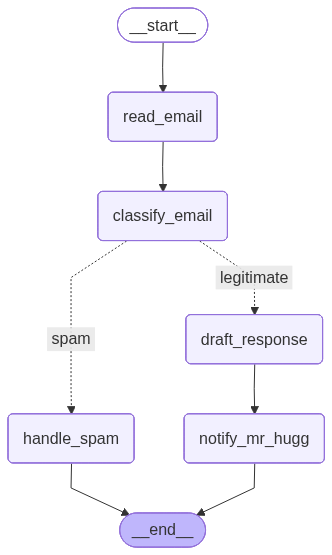

In [8]:
from IPython.display import Image, display

# View
display(Image(compiled_graph.get_graph().draw_mermaid_png()))


In [9]:
#Runs the graph and prints the state change at every node.
def debug_run(graph, initial_state):
    # Use stream mode "updates" to see what each node contributes
    for event in graph.stream(initial_state, stream_mode="updates"):
        for node_name, updated_state in event.items():
            print(f"\n>>> NODE COMPLETED: {node_name}")
            
            # Check if updated_state is not None and is a dictionary
            if updated_state is not None and isinstance(updated_state, dict):
                print(f"--- State Update (Changes) ---")
                # We print the parts of the state that actually changed
                for key, value in updated_state.items():
                    # Only print if there's actual data to show
                    if value is not None and value != [] and value != {}:
                        print(f"  {key}: {value}")
            else:
                print("--- No state changes reported by this node ---")
            # --- FIX ENDS HERE ---

    print("\n>>> WORKFLOW FINISHED <<<")


# Use this instead of .invoke() during development
debug_run(compiled_graph, {"email": legitimate_email, "messages": []})


Alfred is processing an email from john.smith@example.com with subject: Question about your services

>>> NODE COMPLETED: read_email
--- No state changes reported by this node ---

>>> NODE COMPLETED: classify_email
--- State Update (Changes) ---
  is_spam: False
  email_category: inquiry
  messages: [{'role': 'user', 'content': '\n    As Alfred the butler, analyze this email and provide your analysis strictly in JSON format.\n\n    Email:\n    From: john.smith@example.com\n    Subject: Question about your services\n    Body: Dear Mr. Hugg, I was referred to you by a colleague and I\'m interested in learning more about your consulting services. Could we schedule a call next week? Best regards, John Smith\n\n    Your response must be a valid JSON object with exactly these keys:\n    "is_spam": (boolean true or false),\n    "reason": (a short string explaining why if spam, otherwise null),\n    "category": (one of: "inquiry", "complaint", "thank you", "request", "information", or null)\n